Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..599.0].


(309, 600) (309, 600) (309, 600)
(309, 600, 3) float64 0.0 599.0


(np.float64(-0.5), np.float64(599.5), np.float64(308.5), np.float64(-0.5))

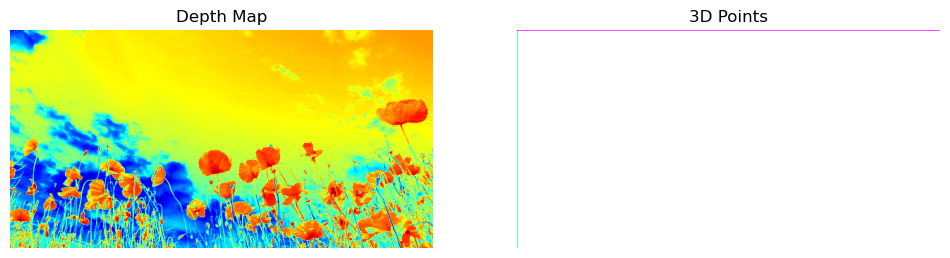

In [ ]:
#### 심화 코드: Depth Map을 기반으로 3D 포인트 클라우드 생성
import cv2
import numpy as np
import matplotlib.pyplot as plt
# 이미지 로드
image = cv2.imread('sample.jpg')
# 그레이스케일 변환
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Depth Map 생성
depth_map = cv2.applyColorMap(gray, cv2.COLORMAP_JET)

# 3D 포인트 클라우드 변환
h, w = depth_map.shape[:2]
X, Y = np.meshgrid(np.arange(w), np.arange(h))
Z = gray.astype(np.float32) # Depth 값을 Z 축으로 사용

print(X.shape, Y.shape, Z.shape)
# 3D 좌표 생성
points_3d = np.dstack((X, Y, Z))
print(points_3d.shape, points_3d.dtype, points_3d.min(), points_3d.max())

# 결과 출력
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 첫 번째 이미지
axes[0].imshow(depth_map, cmap='jet')
axes[0].set_title("Depth Map")
axes[0].axis('off')

# 두 번째 이미지
axes[1].imshow(points_3d, cmap='gray')
axes[1].set_title("3D Points")
axes[1].axis('off')

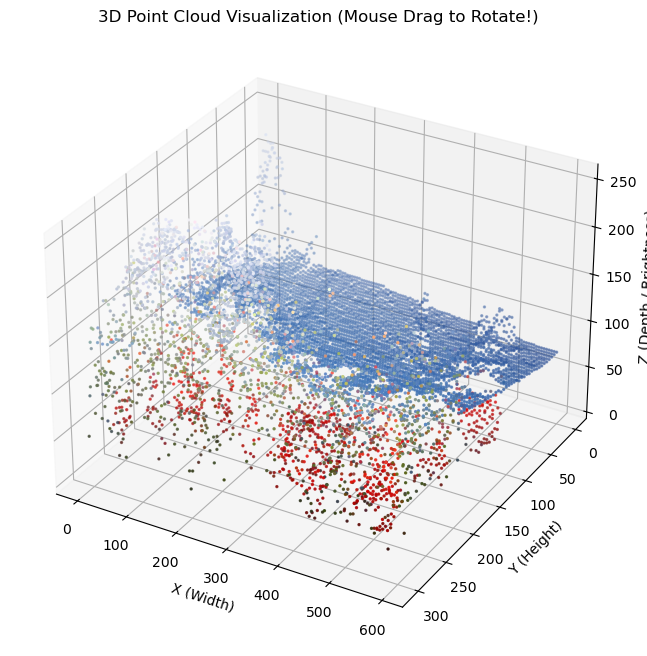

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. 이미지 로드 및 Grayscale 변환
image = cv2.imread("sample.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 2. 3D 포인트 클라우드 좌표 생성
h, w = gray.shape[:2]
X, Y = np.meshgrid(np.arange(w), np.arange(h))
Z = gray.astype(np.float32)

# 3. 렌더링 속도를 위해 5픽셀 간격으로 샘플링 (Downsampling)
step = 5
X_sub = X[::step, ::step].flatten()
Y_sub = Y[::step, ::step].flatten()
Z_sub = Z[::step, ::step].flatten()

# 원래 이미지의 색상(RGB)도 함께 가져와서 3D 점들의 색으로 지정!
color_sub = cv2.cvtColor(image[::step, ::step], cv2.COLOR_BGR2RGB).reshape(
    -1, 3
) / 255.0

# 4. Matplotlib 3D 공간에 점 찍기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# 3D 산점도(Scatter Plot) 그리기
ax.scatter(X_sub, Y_sub, Z_sub, c=color_sub, s=2)

# 시각화 편의를 위해 Y축(위아래)을 뒤집어 사진 방향과 맞춤
ax.invert_yaxis()

ax.set_title("3D Point Cloud Visualization (Mouse Drag to Rotate!)")
ax.set_xlabel("X (Width)")
ax.set_ylabel("Y (Height)")
ax.set_zlabel("Z (Depth / Brightness)")

plt.show()